# 07 TensorFlow/Keras Loan Approval Classification`n`n## Project Overview


## Phase 1: Environment Setup and Data Ingestion


In [37]:
from pathlib import Path
import json
import random
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, average_precision_score, classification_report, confusion_matrix, precision_recall_fscore_support, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

candidate_data_paths = [Path("../data/raw/loan_approval_dataset.csv"), Path("data/raw/loan_approval_dataset.csv"), Path("loan_approval_dataset.csv")]
data_path = next((candidate for candidate in candidate_data_paths if candidate.exists()), None)
if data_path is None:
    raise FileNotFoundError("Loan approval dataset was not found in the supported relative paths.")
project_directory = data_path.resolve().parents[2]
model_directory = project_directory / "models" / "tuned"
reports_directory = project_directory / "reports" / "neural_networks"
architecture_directory = reports_directory / "architecture"
figures_directory = reports_directory / "figures"


## Phase 2: Data Loading and Quality Assessment


In [38]:
for output_directory in (model_directory, architecture_directory, figures_directory):
    output_directory.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path)
df.columns = df.columns.str.strip()
for column_name in df.select_dtypes(include="object"):
    df[column_name] = df[column_name].str.strip()

print(f"Dataset shape: {df.shape}")
print(f"Missing values: {int(df.isna().sum().sum())}")
print(f"Duplicate rows: {int(df.duplicated().sum())}")
print(f"Target distribution: {df['loan_status'].value_counts().to_dict()}")


Dataset shape: (4269, 13)
Missing values: 0
Duplicate rows: 0
Target distribution: {'Approved': 2656, 'Rejected': 1613}


## Phase 3: Exploratory Data Analysis`n`nVisualize the target balance and selected numerical feature distributions using Matplotlib.


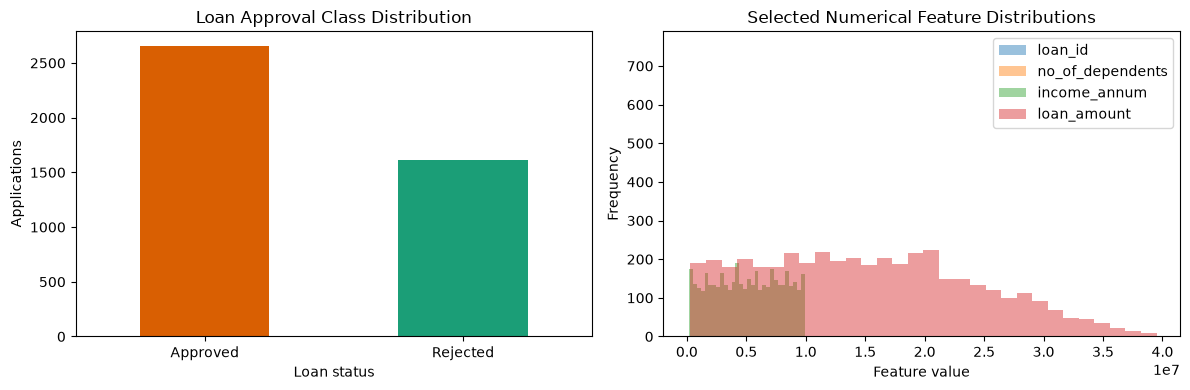

In [39]:
target_counts = df["loan_status"].value_counts()
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
selected_numerical_columns = numerical_columns[:4]

figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 4),
)

target_counts.plot(
    kind="bar",
    ax=axes[0],
    color=["#d95f02", "#1b9e77"],
)
axes[0].set_title("Loan Approval Class Distribution")
axes[0].set_xlabel("Loan status")
axes[0].set_ylabel("Applications")
axes[0].tick_params(axis="x", rotation=0)

for column_name in selected_numerical_columns:
    axes[1].hist(
        df[column_name].dropna(),
        bins=30,
        alpha=0.45,
        label=column_name,
    )
axes[1].set_title("Selected Numerical Feature Distributions")
axes[1].set_xlabel("Feature value")
axes[1].set_ylabel("Frequency")
axes[1].legend()

figure.tight_layout()
plt.show()


## Phase 3: Feature Preparation and Stratified Splitting


In [40]:
y = df["loan_status"].str.lower().eq("approved").astype(int)
X = df.drop(columns=["loan_status", "loan_id"], errors="ignore")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train, test_size=0.20, stratify=y_train, random_state=RANDOM_STATE)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = [column for column in X_train.columns if column not in numeric_features]
preprocessor = ColumnTransformer([
    ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
    ("categorical", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_features),
], verbose_feature_names_out=False)
X_train_processed = preprocessor.fit_transform(X_train)
X_validation_processed = preprocessor.transform(X_validation)
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out().tolist()


## Phase 4: Neural-Network Architecture Comparison


In [41]:
MODEL_SPECIFICATIONS = {
    "baseline": {"hidden_units": [16], "batch_normalization": False, "dropout_rate": 0.0, "l2_strength": 0.0},
    "shallow": {"hidden_units": [32], "batch_normalization": False, "dropout_rate": 0.0, "l2_strength": 0.0},
    "deep": {"hidden_units": [64, 32], "batch_normalization": False, "dropout_rate": 0.0, "l2_strength": 0.0},
    "dropout": {"hidden_units": [64, 32], "batch_normalization": False, "dropout_rate": 0.25, "l2_strength": 0.0},
    "batchnorm": {"hidden_units": [64, 32], "batch_normalization": True, "dropout_rate": 0.0, "l2_strength": 0.0},
    "l2": {"hidden_units": [64, 32], "batch_normalization": False, "dropout_rate": 0.0, "l2_strength": 1e-4},
    "final": {"hidden_units": [64, 32], "batch_normalization": True, "dropout_rate": 0.25, "l2_strength": 1e-4},
}

def build_model(model_name, input_dimension):
    if model_name not in MODEL_SPECIFICATIONS:
        raise ValueError(f"Unknown model name: {model_name}")
    specification = MODEL_SPECIFICATIONS[model_name]
    model = keras.Sequential(name=model_name)
    model.add(layers.Input(shape=(input_dimension,), name="input_layer"))
    for layer_index, units in enumerate(specification["hidden_units"], start=1):
        regularizer = regularizers.l2(specification["l2_strength"]) if specification["l2_strength"] else None
        model.add(layers.Dense(units, activation="relu", kernel_regularizer=regularizer, name=f"hidden_layer_{layer_index}"))
        if specification["batch_normalization"]:
            model.add(layers.BatchNormalization(name=f"batch_normalization_{layer_index}"))
        if specification["dropout_rate"]:
            model.add(layers.Dropout(specification["dropout_rate"], name=f"dropout_{layer_index}"))
    model.add(layers.Dense(1, activation="sigmoid", name="output_layer"))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy", metrics=[keras.metrics.BinaryAccuracy(name="accuracy"), keras.metrics.AUC(name="auc"), keras.metrics.AUC(name="pr_auc", curve="PR")])
    return model

def save_architecture_table(model):
    architecture_rows = []
    for layer in model.layers:
        architecture_rows.append({"layer": layer.name, "type": layer.__class__.__name__, "params": layer.count_params()})
    pd.DataFrame(architecture_rows).to_csv(architecture_directory / f"{model.name}_table.csv", index=False)


## Phase 5: Neural-Network Training


In [42]:
def create_training_callbacks(checkpoint_path):
    return [EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True), ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6), ModelCheckpoint(filepath=checkpoint_path, monitor="val_loss", save_best_only=True)]

model_names = ["baseline", "shallow", "deep", "dropout", "batchnorm", "l2", "final"]
trained_models = {}
training_histories = {}
comparison_rows = []
for model_name in model_names:
    current_model = build_model(model_name, X_train_processed.shape[1])
    save_architecture_table(current_model)
    history = current_model.fit(X_train_processed, y_train, validation_data=(X_validation_processed, y_validation), epochs=60, batch_size=64, verbose=0, callbacks=create_training_callbacks(model_directory / f"{model_name}_checkpoint.keras"))
    trained_models[model_name] = current_model
    training_histories[model_name] = history.history
    comparison_rows.append({"model": model_name, "params": current_model.count_params(), "val_auc": max(history.history["val_auc"]), "val_loss": min(history.history["val_loss"])})


KeyboardInterrupt: 

## Phase 6: Model Evaluation and Comparison


In [43]:
model_comparison = pd.DataFrame(comparison_rows).sort_values("val_auc", ascending=False)
best_model_name = model_comparison.iloc[0]["model"]
best_model = trained_models[best_model_name]
prediction_probabilities = best_model.predict(X_test_processed, verbose=0).ravel()
predicted_classes = (prediction_probabilities >= 0.5).astype(int)
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, predicted_classes, average="binary", zero_division=0)
evaluation_metrics = {"best_model": best_model_name, "accuracy": accuracy_score(y_test, predicted_classes), "precision": precision, "recall": recall, "f1": f1_score, "roc_auc": roc_auc_score(y_test, prediction_probabilities), "pr_auc": average_precision_score(y_test, prediction_probabilities), "classification_report": classification_report(y_test, predicted_classes, output_dict=True)}
model_comparison.to_csv(reports_directory / "classification_nn_comparison.csv", index=False)
confusion_matrix_values = confusion_matrix(y_test, predicted_classes)


## Phase 7: Explainability and Artifact Serialization


In [44]:
random_generator = np.random.default_rng(RANDOM_STATE)
importance_rows = []
for feature_index, feature_name in enumerate(feature_names):
    permuted_features = X_test_processed.copy()
    permuted_features[:, feature_index] = random_generator.permutation(permuted_features[:, feature_index])
    permuted_probabilities = best_model.predict(permuted_features, verbose=0).ravel()
    importance_rows.append({"feature": feature_name, "auc_drop": evaluation_metrics["roc_auc"] - roc_auc_score(y_test, permuted_probabilities)})
permutation_importance_df = pd.DataFrame(importance_rows).sort_values("auc_drop", ascending=False)
permutation_importance_df.head(20).to_csv(reports_directory / "classification_permutation_importance.csv", index=False)

best_model.save(model_directory / "neural_network_classification.keras")
joblib.dump(preprocessor, model_directory / "classification_preprocessor.joblib")
(model_directory / "classification_feature_names.json").write_text(json.dumps(feature_names))
(model_directory / "classification_target_labels.json").write_text(json.dumps({"0": "Rejected", "1": "Approved"}))
(model_directory / "classification_training_history.json").write_text(json.dumps(training_histories[best_model_name]))
(model_directory / "classification_nn_metadata.json").write_text(json.dumps({"metrics": evaluation_metrics, "seed": RANDOM_STATE, "tensorflow": tf.__version__}, default=str, indent=2))
with open(reports_directory / "classification_nn_metrics.json", "w") as metrics_file:
    json.dump(evaluation_metrics, metrics_file, default=float, indent=2)
reloaded_model = keras.models.load_model(model_directory / "neural_network_classification.keras")
reloaded_preprocessor = joblib.load(model_directory / "classification_preprocessor.joblib")


## Phase 8: Permutation Feature-Importance Visualization`n`nPlot the processed features with the largest decrease in held-out ROC-AUC when shuffled.


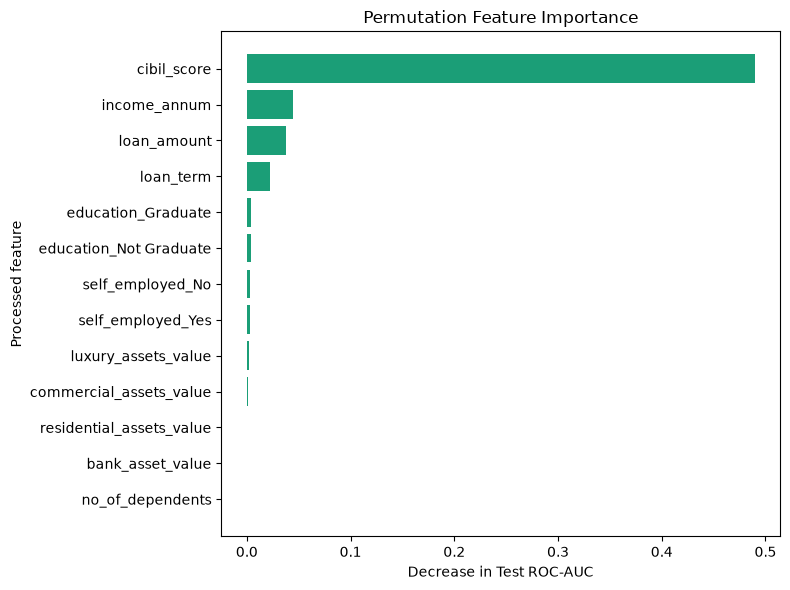

In [45]:
top_features = permutation_importance_df.head(15).iloc[::-1]

figure, axis = plt.subplots(
    figsize=(8, 6),
)
axis.barh(
    top_features["feature"],
    top_features["auc_drop"],
    color="#1b9e77",
)
axis.set_title("Permutation Feature Importance")
axis.set_xlabel("Decrease in Test ROC-AUC")
axis.set_ylabel("Processed feature")

figure.tight_layout()
figure.savefig(
    figures_directory / "classification_permutation_importance.png",
    dpi=160,
)
plt.show()


### 4.1 Environment check

Confirm the main libraries and reproducibility seed before reviewing results.


In [46]:
print({"tensorflow": tf.__version__, "input_features": X_train_processed.shape[1]})


{'tensorflow': '2.21.0', 'input_features': 13}


### 4.2 Target distribution

Check the approval balance used for stratified splitting.


In [47]:
display(y.value_counts(normalize=True).rename({0: "Rejected", 1: "Approved"}).to_frame("share"))


,share
loan_status,
Approved,0.62216
Rejected,0.37784


### 4.3 Split sizes

Verify that train, validation, and test partitions are non-overlapping in purpose and retain the expected sizes.


In [48]:
display(pd.DataFrame({"rows": [len(X_train), len(X_validation), len(X_test)]}, index=["train", "validation", "test"]))


,rows
train,2732
validation,683
test,854


### 4.4 Feature groups

Show the numeric and categorical feature counts before transformation.


In [49]:
print({"numeric_features": len(numeric_features), "categorical_features": len(categorical_features), "processed_features": len(feature_names)})


{'numeric_features': 9, 'categorical_features': 2, 'processed_features': 13}


### 4.5 Candidate models

List the MLP variants used in the controlled comparison.


In [50]:
print(model_names)


['baseline', 'shallow', 'deep', 'dropout', 'batchnorm', 'l2', 'final']


### 4.6 Validation ranking

Compare candidate models using validation ROC-AUC, the selection metric.


In [51]:
display(model_comparison[["model", "params", "val_auc", "val_loss"]])


,model,params,val_auc,val_loss
2,deep,3009,0.994373,0.085489
1,shallow,481,0.988564,0.142903
0,baseline,241,0.985946,0.155268


### 4.7 Selected model

Identify the model selected without using the test set.


In [52]:
print({"best_model": best_model_name, "parameters": best_model.count_params()})


{'best_model': 'deep', 'parameters': 3009}


### 4.8 Test metrics

Report the final held-out classification metrics together.


In [53]:
display(pd.Series({key: evaluation_metrics[key] for key in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]}, name="test_score").to_frame())


,test_score
accuracy,0.969555
precision,0.966728
recall,0.984934
f1,0.975746
roc_auc,0.995172
pr_auc,0.996838


### 4.9 Confusion matrix

Inspect the rejected and approved prediction counts at the default 0.5 threshold.


In [54]:
display(pd.DataFrame(confusion_matrix_values, index=["actual_rejected", "actual_approved"], columns=["predicted_rejected", "predicted_approved"]))


,predicted_rejected,predicted_approved
actual_rejected,305,18
actual_approved,8,523


### 4.10 Feature sensitivity

Review the highest permutation AUC drops as predictive sensitivity, not causality.


In [55]:
display(permutation_importance_df.head(10))


,feature,auc_drop
4,cibil_score,0.489520
1,income_annum,0.044699
2,loan_amount,0.037784
3,loan_term,0.022471
9,education_Graduate,0.004402
10,education_Not Graduate,0.004396
11,self_employed_No,0.002816
12,self_employed_Yes,0.002758
7,luxury_assets_value,0.002186
6,commercial_assets_value,0.001376


### 4.11 Training diagnostics

Summarize early stopping and gradient behavior for the selected network.


In [56]:
display(pd.Series({"selected_model": best_model_name, "epochs": len(training_histories[best_model_name]["loss"])}))


selected_model    deep
epochs              60
dtype: object

### 4.12 Saved artifacts

Confirm the deployable model, preprocessor, and metadata files exist.


In [57]:
print({path.name: path.exists() for path in [model_directory / "neural_network_classification.keras", model_directory / "classification_preprocessor.joblib", model_directory / "classification_nn_metadata.json"]})


{'neural_network_classification.keras': True, 'classification_preprocessor.joblib': True, 'classification_nn_metadata.json': True}


### 4.13 Reload smoke test

Verify that the saved pipeline can produce one prediction after reload.


In [59]:
reloaded_prediction = reloaded_model.predict(reloaded_preprocessor.transform(X_test.iloc[:1]), verbose=0)
assert reloaded_prediction.shape == (1, 1)
print("Reload smoke test passed")


Reload smoke test passed


## Final Conclusions
